<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/QUIZ_TEST_2_AHMAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: IMPORT LIBRARIES FOR GENERAL & MACHINE LEARNING
# ============================================================
import os, re, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit‑learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Kaggle dataset downloader
import kagglehub

# Download NLTK data (run once)
nltk.download('stopwords', quiet=True)

True

In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES FOR NEURAL NETWORK (TensorFlow/Keras)
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ============================================================
# CELL 3: DOWNLOAD DATASET FROM KAGGLE
# ============================================================
print("📥 Downloading Fake & Real News Dataset from Kaggle...")
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print(f"✅ Dataset path: {path}")

# List files
files = os.listdir(path)
print(f"Files: {files}")

# Load CSV files
fake_df = pd.read_csv(os.path.join(path, "Fake.csv"))
true_df = pd.read_csv(os.path.join(path, "True.csv"))

# Add labels
fake_df['label'] = 1   # Fake
true_df['label'] = 0   # Real

# Concatenate
df = pd.concat([fake_df, true_df], ignore_index=True)

print(f"\n✅ Data loaded:")
print(f"   Fake news samples : {fake_df.shape[0]}")
print(f"   Real news samples : {true_df.shape[0]}")
print(f"   Total samples      : {df.shape[0]}")
print(f"   Columns            : {df.columns.tolist()}")

📥 Downloading Fake & Real News Dataset from Kaggle...
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
✅ Dataset path: /kaggle/input/fake-and-real-news-dataset
Files: ['True.csv', 'Fake.csv']

✅ Data loaded:
   Fake news samples : 23481
   Real news samples : 21417
   Total samples      : 44898
   Columns            : ['title', 'text', 'subject', 'date', 'label']


In [ ]:
# ============================================================
# CELL 4: TEXT CLEANING & PREPROCESSING
# ============================================================
def clean_text(text):
    """Remove HTML, punctuation, numbers, extra spaces and lower case."""
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🔧 Cleaning text...")
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text']  = df['text'].apply(clean_text)

# Remove very short texts
df = df[df['clean_text'].str.len() > 50]

# Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=['clean_text'])
print(f"   Removed {before - len(df)} duplicate texts")

# Simple feature engineering
df['text_length']      = df['clean_text'].apply(len)
df['word_count']       = df['clean_text'].apply(lambda x: len(x.split()))
df['avg_word_length']  = df['text_length'] / df['word_count']
df['uppercase_count']  = df['title'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print(f"✅ Cleaned data shape: {df.shape}")

🔧 Cleaning text...
   Removed 5830 duplicate texts
✅ Cleaned data shape: (38220, 11)


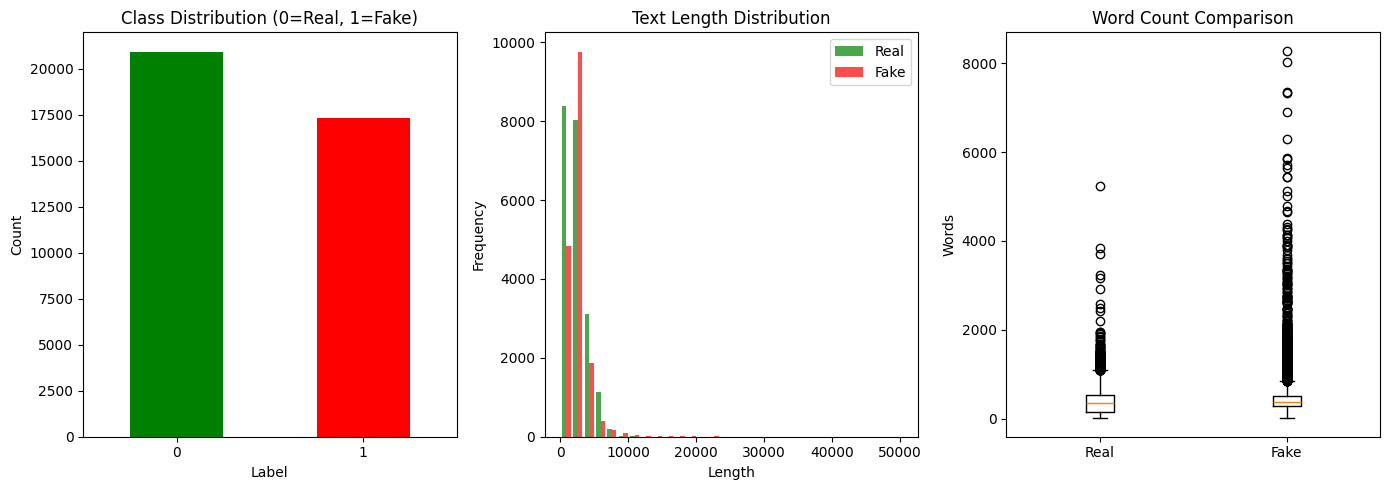

In [ ]:
# ============================================================
# CELL 5: EXPLORATORY DATA ANALYSIS (OPTIONAL BUT INFORMATIVE)
# ============================================================
plt.figure(figsize=(14,5))

# class distribution
plt.subplot(1,3,1)
df['label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Class Distribution (0=Real, 1=Fake)')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=0)

# text length distribution
plt.subplot(1,3,2)
fake_len = df[df['label']==1]['text_length']
real_len = df[df['label']==0]['text_length']
plt.hist([real_len, fake_len], bins=30, label=['Real','Fake'], color=['green','red'], alpha=0.7)
plt.title('Text Length Distribution')
plt.xlabel('Length'); plt.ylabel('Frequency')
plt.legend()

# word count boxplot
plt.subplot(1,3,3)
fake_wc = df[df['label']==1]['word_count']
real_wc = df[df['label']==0]['word_count']
plt.boxplot([real_wc, fake_wc], labels=['Real','Fake'])
plt.title('Word Count Comparison')
plt.ylabel('Words')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 6: TF‑IDF VECTORIZATION & TRAIN/TEST SPLIT
# ============================================================
print("🔢 Creating TF‑IDF features (max 5000, 1–2 grams)...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label'].values

print(f"   Feature matrix shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples    : {X_test.shape[0]}")
print(f"   Number of features: {X_train.shape[1]}")

🔢 Creating TF‑IDF features (max 5000, 1–2 grams)...
   Feature matrix shape: (38220, 5000)
   Training samples: 30576
   Test samples    : 7644
   Number of features: 5000


In [ ]:
# ============================================================
# CELL 7: MACHINE LEARNING MODELS (Logistic Regression, NB, RF)
#         – Training & Testing Accuracy (with all metrics)
# ============================================================
def evaluate_ml_model(name, model, X_train, y_train, X_test, y_test):
    """Train and evaluate a scikit‑learn model, returning metrics."""
    model.fit(X_train, y_train)

    # Training accuracy
    train_pred = model.predict(X_train)
    train_acc  = accuracy_score(y_train, train_pred)

    # Test predictions
    test_pred   = model.predict(X_test)
    test_proba  = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    test_acc    = accuracy_score(y_test, test_pred)
    precision   = precision_score(y_test, test_pred)
    recall      = recall_score(y_test, test_pred)
    f1          = f1_score(y_test, test_pred)
    roc_auc     = roc_auc_score(y_test, test_proba) if test_proba is not None else None

    return {'Model': name,
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc}

ml_results = []

# 1. Logistic Regression
print("🟢 Logistic Regression training...")
lr = LogisticRegression(max_iter=1000, random_state=42)
ml_results.append(evaluate_ml_model('Logistic Regression', lr, X_train, y_train, X_test, y_test))

# 2. Naive Bayes
print("🟡 Naive Bayes training...")
nb = MultinomialNB()
ml_results.append(evaluate_ml_model('Naive Bayes', nb, X_train, y_train, X_test, y_test))

# 3. Random Forest
print("🔴 Random Forest training...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
ml_results.append(evaluate_ml_model('Random Forest', rf, X_train, y_train, X_test, y_test))

# Display ML results
ml_df = pd.DataFrame(ml_results)
print("\n📊 Machine Learning Models Performance:")
print(ml_df.round(4).to_string(index=False))

🟢 Logistic Regression training...
🟡 Naive Bayes training...
🔴 Random Forest training...

📊 Machine Learning Models Performance:
              Model  Train_Accuracy  Test_Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression          0.9898         0.9848     0.9915  0.9749    0.9831   0.9984
        Naive Bayes          0.9471         0.9444     0.9457  0.9306    0.9381   0.9848
      Random Forest          0.9932         0.9870     0.9991  0.9723    0.9855   0.9991


🧠 Training Neural Network WITH Dropout...
Epoch 1/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9656 - loss: 0.1033 - val_accuracy: 0.9844 - val_loss: 0.0473
Epoch 2/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9943 - loss: 0.0185 - val_accuracy: 0.9867 - val_loss: 0.0451
Epoch 3/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9972 - loss: 0.0096 - val_accuracy: 0.9880 - val_loss: 0.0472
Epoch 4/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9986 - loss: 0.0045 - val_accuracy: 0.9869 - val_loss: 0.0604
Epoch 5/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9991 - loss: 0.0027 - val_accuracy: 0.9880 - val_loss: 0.0613
Epoch 6/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9877 - val_loss: 0.0689
Epoch 7/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9876 - val_loss: 0.0837
Epoch 8/30
956/956 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accurac

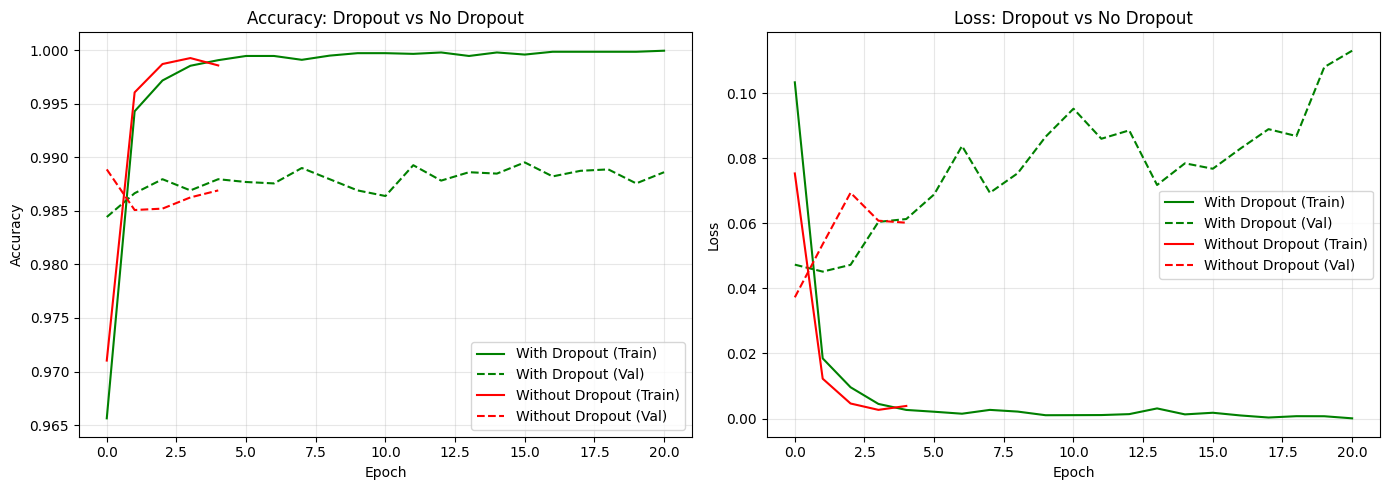

In [ ]:
# ============================================================
# CELL 8: NEURAL NETWORK MODEL (WITH & WITHOUT DROPOUT)
#         Training/Validation accuracy, loss plots
# ============================================================
def build_nn(use_dropout=True):
    layers = [
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    ]
    if use_dropout:
        layers.append(Dropout(0.5))
    layers.append(Dense(128, activation='relu'))
    if use_dropout:
        layers.append(Dropout(0.5))
    layers.append(Dense(64, activation='relu'))
    if use_dropout:
        layers.append(Dropout(0.3))
    layers.append(Dense(1, activation='sigmoid'))

    model = Sequential(layers)
    model.compile(optimizer=Adam(0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=0)

# Train WITH Dropout
print("🧠 Training Neural Network WITH Dropout...")
nn_with = build_nn(use_dropout=True)
history_with = nn_with.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32,
    callbacks=[early_stop], verbose=1
)
y_pred_nn   = (nn_with.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
y_proba_nn  = nn_with.predict(X_test, verbose=0).flatten()
nn_acc_test = accuracy_score(y_test, y_pred_nn)

# Train WITHOUT Dropout
print("\n🧠 Training Neural Network WITHOUT Dropout...")
nn_without = build_nn(use_dropout=False)
history_without = nn_without.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32,
    callbacks=[early_stop], verbose=1
)

# ---------- Overfitting Comparison Plots ----------
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Accuracy
axes[0].plot(history_with.history['accuracy'], 'g-', label='With Dropout (Train)')
axes[0].plot(history_with.history['val_accuracy'], 'g--', label='With Dropout (Val)')
axes[0].plot(history_without.history['accuracy'], 'r-', label='Without Dropout (Train)')
axes[0].plot(history_without.history['val_accuracy'], 'r--', label='Without Dropout (Val)')
axes[0].set_title('Accuracy: Dropout vs No Dropout')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_with.history['loss'], 'g-', label='With Dropout (Train)')
axes[1].plot(history_with.history['val_loss'], 'g--', label='With Dropout (Val)')
axes[1].plot(history_without.history['loss'], 'r-', label='Without Dropout (Train)')
axes[1].plot(history_without.history['val_loss'], 'r--', label='Without Dropout (Val)')
axes[1].set_title('Loss: Dropout vs No Dropout')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Store NN metrics for final comparison
nn_metrics = {
    'Model': 'Neural Network (Dropout)',
    'Train_Accuracy': history_with.history['accuracy'][-1],  # last training accuracy
    'Test_Accuracy': nn_acc_test,
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1-Score': f1_score(y_test, y_pred_nn),
    'ROC-AUC': roc_auc_score(y_test, y_proba_nn)
}
ml_results.append(nn_metrics)


📊 FINAL MODEL COMPARISON (Training vs Test Accuracy):
                   Model  Train_Accuracy  Test_Accuracy  Precision  Recall  F1-Score  ROC-AUC
     Logistic Regression          0.9898         0.9848     0.9915  0.9749    0.9831   0.9984
             Naive Bayes          0.9471         0.9444     0.9457  0.9306    0.9381   0.9848
           Random Forest          0.9932         0.9870     0.9991  0.9723    0.9855   0.9991
Neural Network (Dropout)          1.0000         0.9895     0.9890  0.9879    0.9884   0.9987


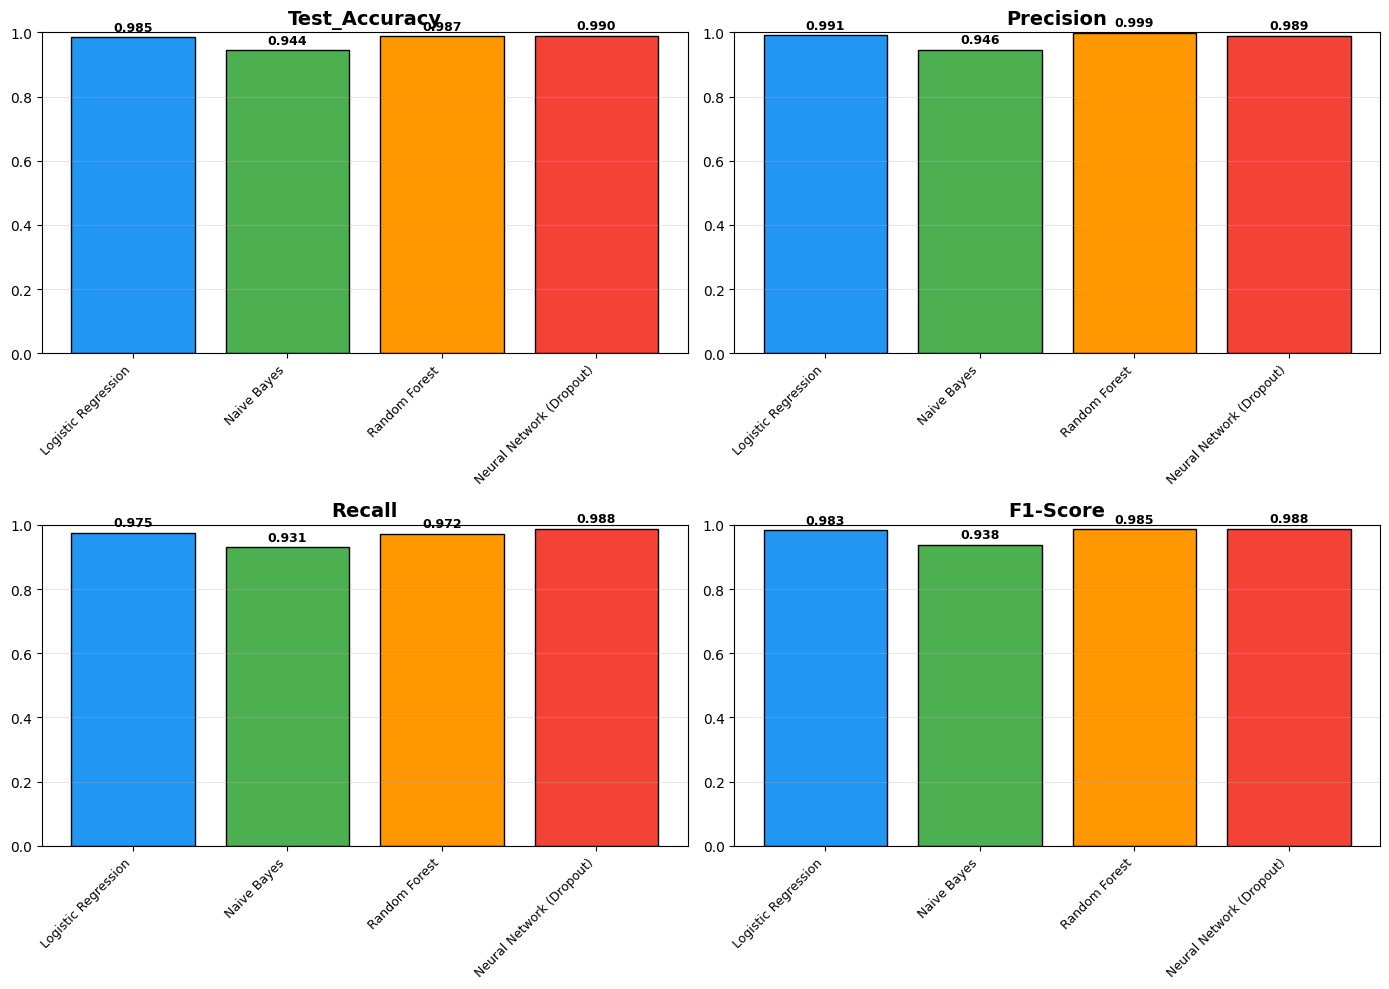


🏆 Best Model (based on Test Accuracy): Neural Network (Dropout) (0.9895)


In [ ]:
# ============================================================
# CELL 9: FINAL MODEL COMPARISON (ML + NN)
# ============================================================
final_df = pd.DataFrame(ml_results)
print("\n📊 FINAL MODEL COMPARISON (Training vs Test Accuracy):")
print("="*65)
print(final_df.round(4).to_string(index=False))

# Visual comparison
metrics = ['Test_Accuracy','Precision','Recall','F1-Score']
fig, axes = plt.subplots(2,2, figsize=(14,10))
colors = ['#2196F3','#4CAF50','#FF9800','#F44336']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    values = final_df[metric].values
    models = final_df['Model'].values
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

best_idx = final_df['Test_Accuracy'].idxmax()
best_model = final_df.iloc[best_idx]['Model']
best_acc   = final_df.iloc[best_idx]['Test_Accuracy']
print(f"\n🏆 Best Model (based on Test Accuracy): {best_model} ({best_acc:.4f})")

In [ ]:
# ============================================================
# CELL 10: USER INPUT PREDICTION SYSTEM (Supports all models)
# ============================================================
def predict_user_news():
    """
    Interactive function that asks the user for a news text and
    a model choice, then displays the prediction.
    """
    print("\n🔮 Fake News Detection – User Input")
    print("Models: 'lr' (Logistic Regression), 'rf' (Random Forest),")
    print("        'nb' (Naive Bayes), 'nn' (Neural Network)\n")

    while True:
        user_choice = input("👉 Choose model (lr/rf/nb/nn) or 'exit': ").strip().lower()
        if user_choice == 'exit':
            print("👋 Goodbye!")
            break
        if user_choice not in ['lr','rf','nb','nn']:
            print("❌ Invalid choice. Please choose lr, rf, nb, nn, or exit.")
            continue

        news_text = input("📝 Enter news text: ").strip()
        if not news_text:
            print("❌ Empty text! Try again.")
            continue

        # Clean and vectorize
        cleaned = clean_text(news_text)
        features = tfidf.transform([cleaned]).toarray()

        # Select model
        if user_choice == 'lr':
            proba = lr.predict_proba(features)[0]
            pred = lr.predict(features)[0]
            model_name = "Logistic Regression"
        elif user_choice == 'rf':
            proba = rf.predict_proba(features)[0]
            pred = rf.predict(features)[0]
            model_name = "Random Forest"
        elif user_choice == 'nb':
            proba = nb.predict_proba(features)[0]
            pred = nb.predict(features)[0]
            model_name = "Naive Bayes"
        else:  # nn
            proba_nn = nn_with.predict(features, verbose=0)[0][0]
            proba = [1 - proba_nn, proba_nn]
            pred = 1 if proba_nn > 0.5 else 0
            model_name = "Neural Network"

        confidence = max(proba) * 100
        label = "🛑 FAKE NEWS" if pred == 1 else "✅ REAL NEWS"

        print(f"\n📊 Prediction by {model_name}:")
        print(f"   Verdict   : {label}")
        print(f"   Confidence: {confidence:.1f}%")
        print(f"   Real prob : {proba[0]*100:.1f}%")
        print(f"   Fake prob : {proba[1]*100:.1f}%")
        print("-"*50)

# Run the interactive system
predict_user_news()


🔮 Fake News Detection – User Input
Models: 'lr' (Logistic Regression), 'rf' (Random Forest),
        'nb' (Naive Bayes), 'nn' (Neural Network)

👉 Choose model (lr/rf/nb/nn) or 'exit': nn
📝 Enter news text: "BREAKING: Scientists discover that drinking bleach can cure cancer instantly! The mainstream media doesn't want you to know this secret. Share this life-saving information with everyone you know before it's banned!"

📊 Prediction by Neural Network:
   Verdict   : 🛑 FAKE NEWS
   Confidence: 100.0%
   Real prob : 0.0%
   Fake prob : 100.0%
--------------------------------------------------
👉 Choose model (lr/rf/nb/nn) or 'exit': lr
📝 Enter news text: BREAKING: Scientists discover that drinking bleach can cure cancer instantly! The mainstream media doesn't want you to know this secret. Share this life-saving information with everyone you know before it's banned!

📊 Prediction by Logistic Regression:
   Verdict   : 🛑 FAKE NEWS
   Confidence: 97.3%
   Real prob : 2.7%
   Fake prob : 97.

In [ ]:
# ============================================================
# CELL : SAVE ALL MODELS & VECTORIZER TO GOOGLE DRIVE
# ============================================================
import pickle, os
from google.colab import drive
drive.mount('/content/drive')

# Create a dedicated folder for your project
save_folder = '/content/drive/MyDrive/fake_news_models'
os.makedirs(save_folder, exist_ok=True)

# 1. Save TF‑IDF vectorizer
with open(f'{save_folder}/tfidf_vectorizer_fakenews.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 2. Save Machine Learning models (with clear names)
with open(f'{save_folder}/logistic_regression_fakenews.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open(f'{save_folder}/naive_bayes_fakenews.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open(f'{save_folder}/random_forest_fakenews.pkl', 'wb') as f:
    pickle.dump(rf, f)

# 3. Save Neural Network (Keras HDF5 format)
nn_with.save(f'{save_folder}/neural_network_fakenews.h5')

print("✅ All models and vectorizer saved successfully!")
print(f"   Location : {save_folder}")
print("   Files    : tfidf_vectorizer_fakenews.pkl")
print("              logistic_regression_fakenews.pkl")
print("              naive_bayes_fakenews.pkl")
print("              random_forest_fakenews.pkl")
print("              neural_network_fakenews.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All models and vectorizer saved successfully!
   Location : /content/drive/MyDrive/fake_news_models
   Files    : tfidf_vectorizer_fakenews.pkl
              logistic_regression_fakenews.pkl
              naive_bayes_fakenews.pkl
              random_forest_fakenews.pkl
              neural_network_fakenews.h5


In [ ]:
# ============================================================
# CELL : LOAD MODELS + USER INPUT PREDICTION SYSTEM
# ============================================================
import pickle, os, re
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# ---------- 1. Load vectorizer & all models ----------
load_path = '/content/drive/MyDrive/fake_news_models'

with open(f'{load_path}/tfidf_vectorizer_fakenews.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open(f'{load_path}/logistic_regression_fakenews.pkl', 'rb') as f:
    lr = pickle.load(f)

with open(f'{load_path}/naive_bayes_fakenews.pkl', 'rb') as f:
    nb = pickle.load(f)

with open(f'{load_path}/random_forest_fakenews.pkl', 'rb') as f:
    rf = pickle.load(f)

from tensorflow.keras.models import load_model
nn_model = load_model(f'{load_path}/neural_network_fakenews.h5')

print("✅ All models and vectorizer loaded!\n")

# ---------- 2. Same cleaning function ----------
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ---------- 3. Prediction function ----------
def predict_news(text, model_choice):
    cleaned = clean_text(text)
    features = tfidf.transform([cleaned]).toarray()

    if model_choice == 'lr':
        proba = lr.predict_proba(features)[0]
        pred = lr.predict(features)[0]
        model_name = "Logistic Regression"
    elif model_choice == 'rf':
        proba = rf.predict_proba(features)[0]
        pred = rf.predict(features)[0]
        model_name = "Random Forest"
    elif model_choice == 'nb':
        proba = nb.predict_proba(features)[0]
        pred = nb.predict(features)[0]
        model_name = "Naive Bayes"
    elif model_choice == 'nn':
        proba_nn = nn_model.predict(features, verbose=0)[0][0]
        proba = [1 - proba_nn, proba_nn]
        pred = 1 if proba_nn > 0.5 else 0
        model_name = "Neural Network"
    else:
        print("❌ Invalid model choice.")
        return

    confidence = max(proba) * 100
    label = "🛑 FAKE NEWS" if pred == 1 else "✅ REAL NEWS"

    print(f"\n📊 Prediction by {model_name}:")
    print(f"   Verdict    : {label}")
    print(f"   Confidence : {confidence:.1f}%")
    print(f"   Real prob  : {proba[0]*100:.1f}%")
    print(f"   Fake prob  : {proba[1]*100:.1f}%")
    print("-" * 60)

# ---------- 4. Interactive loop ----------
print("🔮 Fake News Detector – Using saved models\n")
print("Choose model: 'lr' (Logistic Regression)")
print("              'rf' (Random Forest)")
print("              'nb' (Naive Bayes)")
print("              'nn' (Neural Network)")
print("Type 'exit' to quit.\n")

while True:
    model_choice = input("👉 Model (lr/rf/nb/nn): ").strip().lower()
    if model_choice == 'exit':
        print("👋 Goodbye!")
        break
    if model_choice not in ['lr', 'rf', 'nb', 'nn']:
        print("❌ Please enter lr, rf, nb, nn, or exit.\n")
        continue

    news_text = input("📝 News text: ").strip()
    if not news_text:
        print("❌ Empty text – try again.\n")
        continue

    predict_news(news_text, model_choice)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ All models and vectorizer loaded!

🔮 Fake News Detector – Using saved models

Choose model: 'lr' (Logistic Regression)
              'rf' (Random Forest)
              'nb' (Naive Bayes)
              'nn' (Neural Network)
Type 'exit' to quit.

👉 Model (lr/rf/nb/nn): nn
📝 News text: BREAKING: Scientists discover that drinking bleach can cure cancer instantly! The mainstream media doesn't want you to know this secret. Share this life-saving information with everyone you know before it's banned!

📊 Prediction by Neural Network:
   Verdict    : 🛑 FAKE NEWS
   Confidence : 100.0%
   Real prob  : 0.0%
   Fake prob  : 100.0%
------------------------------------------------------------
👉 Model (lr/rf/nb/nn): exit
👋 Goodbye!
